<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 4: Sequence Models

**University of Maryland, College Park**  
**Fall 2025**  
**Instructor**: Armin Mehrabian  
**Date**: September 22–23, 2025  



<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 1. Probabilistic Language Models



# Probabilistic Language Models  

**Goal:** Use probability to decide which sentence is more natural.  


**Applications**  

- **Machine Translation:**  
  $P(\text{strong rain tomorrow}) > P(\text{big rain tomorrow})$  

- **Spell Checking:**  
  *She wants to eat **desert***  
  - $P(\text{eat dessert}) > P(\text{eat desert})$  

- **Speech Recognition:**  
  $P(\text{recognize speech}) \gg P(\text{wreck a nice beach})$  



# Probabilistic Language Modeling (1/2)  

**Goal:**  
Compute the probability of a sentence or sequence of words:  

$$
P(W) = P(w_1, w_2, w_3, \dots, w_n)
$$  


# Probabilistic Language Modeling (2/2)  

**Related task:**  
Compute the probability of the next word given the history:  

$$
P(w_{t} \mid w_1, w_2, \dots, w_{t-1})
$$  

**Definition:**  
A model that estimates either $P(W)$ or $P(w_t \mid w_1, \dots, w_{t-1})$ is called a **language model (LM)**.  

*Note:* In linguistics the term *grammar* is often used, but in NLP the standard term is **language model**.


# How to Compute $P(W)$  

**Question:** How do we calculate the probability of an entire sentence?  

Example joint probability:  

$$
P(\text{the}, \text{cat}, \text{sat}, \text{on}, \text{the}, \text{mat})
$$  

**Intuition:**  
We rely on the **Chain Rule of Probability** to decompose this joint probability into a sequence of conditional probabilities.


# Reminder: Conditional Probability  

**Definition:**  

$$
P(A \mid B) = \frac{P(A, B)}{P(B)}
$$  

Rearranged:  

$$
P(A, B) = P(A \mid B) \, P(B)
$$  


# Reminder: The Chain Rule  

For multiple variables:  

$$
P(A, B, C, D) = P(A) \, P(B \mid A) \, P(C \mid A, B) \, P(D \mid A, B, C)
$$  

**In general:**  

$$
P(x_1, x_2, \dots, x_n) = \prod_{t=1}^n P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$  


# The Chain Rule for Sentence Probability  

The joint probability of a sequence of words can be decomposed using the **Chain Rule of Probability**:  

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, w_2, \dots, w_{i-1})
$$  


**Example:**  

For the sentence *"the cat sat down"*  

$$
P(\text{the cat sat down}) = P(\text{the}) \times P(\text{cat} \mid \text{the}) \times P(\text{sat} \mid \text{the cat}) \times P(\text{down} \mid \text{the cat sat})
$$


# Parameter Growth

The generative process quickly becomes complex:  

- $P(w_1)$ requires $O(V)$ parameters  
- $P(w_2 \mid w_1)$ requires $O(V^2)$ parameters  
- $P(w_3 \mid w_1, w_2)$ requires $O(V^3)$ parameters  

Here, $V$ is the size of the vocabulary.  


# How to Estimate Probabilities  

**Idea:** Could we just count and divide?  

Example:  

$$
P(\text{sat} \mid \text{the cat}) 
= \frac{\text{Count}(\text{the cat sat})}{\text{Count}(\text{the cat})}
$$  


**Problem:**  
This method is simple, but there are **too many possible sentences**.  
Most sequences will be unseen in real data.


In [10]:
import nltk
from nltk.corpus import brown
from collections import Counter

# Download corpus if not already
nltk.download("brown")

# Use the first 5000 words for a quick demo
tokens = brown.words()

# Build bigrams
bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]

# Count frequencies
unigram_counts = Counter(tokens)
bigram_counts = Counter(bigrams)

# Example: P(man | the)
num = bigram_counts[("the", "man")]
den = unigram_counts["the"]
prob = num / den if den > 0 else 0

print("P(tall man | the) =", prob)


[nltk_data] Downloading package brown to
[nltk_data]     /Users/arminmehrabian/nltk_data...
[nltk_data]   Package brown is already up-to-date!


P(tall man | the) = 0.002041044121633473


# Estimating from a Real Corpus  

We can compute probabilities directly from counts in a large corpus.  

**Example (Brown corpus):**  

$$
P(\text{tall man} \mid \text{the}) 
= \frac{\text{Count}(\text{the tall man})}{\text{Count}(\text{the})}
\approx 0.002
$$  

**Observation:**  
Even in a large corpus, many reasonable phrases have **very low probabilities**.  
This highlights the **sparsity problem** in language modeling.


# Markov Models (1/2)  

**Key idea:** The **Markov property** assumes that the future depends only on a limited history, not the entire past.  

- **First-order Markov assumption:**  
  $$
  P(w_i \mid w_1, w_2, \dots, w_{i-1}) \;\approx\; P(w_i \mid w_{i-1})
  $$  

- **Bigram model** = first-order Markov approximation  

- This simplification treats the **previous word** as a summary (equivalence class) of all possible histories that end with it.  


# The Simplest Case: Unigram Model  

**Unigram assumption:**  
Each word is chosen independently of the others.  

$$
P(w_1, w_2, \dots, w_n) \;\approx\; \prod_{i=1}^{n} P(w_i)
$$  


**Example: Generated text from a unigram model**  

- *dog, is, a, sat, happy, on, mat*  
- *house, big, the, tree, runs, cat*  


**Observation:**  
- The words are **grammatical individually**, but the sequence is **nonsensical**.  
- This shows that **unigram models ignore context**.  


In [14]:
import random
from collections import Counter, defaultdict
from nltk.corpus import brown

# Use the full Brown corpus
tokens = brown.words()

def build_ngram_model(tokens, order=1):
    """
    Build an n-gram language model of given order.
    
    Parameters:
    - tokens: list of words from the corpus
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    
    Returns:
    - followers: dictionary mapping context → list of next words
    """
    ngrams = [tuple(tokens[i:i+order+1]) for i in range(len(tokens) - order)]
    ngram_counts = Counter(ngrams)

    followers = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context, next_word = ngram[:-1], ngram[-1]
        followers[context].extend([next_word] * count)

    return followers

def generate_sentence(followers, order=1, length=10, start=None):
    """
    Generate a sentence using an n-gram model.
    
    - followers: trained model
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    - length: number of words to generate
    - start: optional start word/tuple. If None, chosen randomly.
    """
    # Pick a valid random start if none provided
    if start is None:
        start = random.choice(list(followers.keys()))
    
    # Ensure start is a tuple
    if not isinstance(start, tuple):
        start = (start,)
    
    # If start length doesn't match order, replace with random context
    if len(start) != order:
        start = random.choice(list(followers.keys()))
    
    # Begin sentence
    sentence = list(start)

    for _ in range(length - len(start)):
        context = tuple(sentence[-order:]) if order > 0 else tuple()
        if context not in followers:
            break
        next_word = random.choice(followers[context])
        sentence.append(next_word)

    return " ".join(sentence)

# -----------------
# Example usage:
# -----------------

# Change order here: 0=unigram, 1=bigram, 2=trigram, etc.
order = 0
model = build_ngram_model(tokens, order=order)

# Generate a sample sentence
print(generate_sentence(model, order=order, length=15))


There with is , a '' weeping -- couldn't . 22nd rights adobe the concentrated


# Markov Model (2/2)  

**Bigram probability of a sequence:**  

$$
P_{\text{bigram}}(w_0, w_1, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_{i-1})
$$  


**In log space:**  

$$
\log P(w_1, \dots, w_n) = \sum_{i=1}^{n} \log P(w_i \mid w_{i-1})
$$  


**Why logs?**  
- Avoids numerical underflow (very small probabilities).  
- Turns multiplication into addition (faster, more stable).  
 


# Special START Token  

**Problem:**  
- In bigram models, the first word $w_1$ has no previous context.  
- Without a fix, $P(w_1 \mid w_{0})$ is undefined.  



**Solution:**  
Introduce a special token:  

- $w_0 = \langle \text{START} \rangle$  
- $P(w_0) = 1$ (certain)  

So the sequence probability becomes:  

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_{i-1})
$$  

with $w_0 = \langle \text{START} \rangle$.  



**Why this matters:**  
- Ensures a **uniform formula** for every word.  
- Teaches the model what words typically begin a sentence.  



**Connection to modern LLMs:**  
- Today’s models also use special tokens:  
  - $\langle \text{BOS} \rangle$, $\langle \text{EOS} \rangle$ for sentence boundaries  
  - $\langle \text{PAD} \rangle$, $\langle \text{MASK} \rangle$, `<CLS>`, `<SEP>` for tasks  
- Idea originated with these early **Markov/N-gram models**.  


In [16]:
import random
from collections import Counter, defaultdict
from nltk.corpus import brown

# Use the full Brown corpus
tokens = brown.words()

def build_ngram_model(tokens, order=1):
    """
    Build an n-gram language model of given order.
    
    Parameters:
    - tokens: list of words from the corpus
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    
    Returns:
    - followers: dictionary mapping context → list of next words
    """
    ngrams = [tuple(tokens[i:i+order+1]) for i in range(len(tokens) - order)]
    ngram_counts = Counter(ngrams)

    followers = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context, next_word = ngram[:-1], ngram[-1]
        followers[context].extend([next_word] * count)

    return followers

def generate_sentence(followers, order=1, length=10, start=None):
    """
    Generate a sentence using an n-gram model.
    
    - followers: trained model
    - order: Markov order (0 = unigram, 1 = bigram, 2 = trigram, etc.)
    - length: number of words to generate
    - start: optional start word/tuple. If None, chosen randomly.
    """
    # Pick a valid random start if none provided
    if start is None:
        start = random.choice(list(followers.keys()))
    
    # Ensure start is a tuple
    if not isinstance(start, tuple):
        start = (start,)
    
    # If start length doesn't match order, replace with random context
    if len(start) != order:
        start = random.choice(list(followers.keys()))
    
    # Begin sentence
    sentence = list(start)

    for _ in range(length - len(start)):
        context = tuple(sentence[-order:]) if order > 0 else tuple()
        if context not in followers:
            break
        next_word = random.choice(followers[context])
        sentence.append(next_word)

    return " ".join(sentence)

# -----------------
# Example usage:
# -----------------

# Change order here: 0=unigram, 1=bigram, 2=trigram, etc.
order = 1
model = build_ngram_model(tokens, order=order)

# Generate a sample sentence
print(generate_sentence(model, order=order, length=15))


quality of these places . Circuit Court for compost and employers in a Monday .


# N-gram Models: Limitations  

- We can extend to trigrams, 4-grams, 5-grams, etc.  
- But in general, this is still an **insufficient model of language**  
  - because natural language often has **long-distance dependencies**  


**Example:**  

*"The book that the professor recommended during the seminar was fascinating."*  

- The word *"book"* (subject) connects to *"was fascinating"* (verb + predicate).  
- An N-gram model with only short context may fail to capture this relationship.  


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 2. Language Model Evaluation



# Language Model Evaluation (1/2)  

**What makes a good language model (LM)?**  
It assigns high probability to sentences in the test set.  

---

- **Goal:**  
  Estimate $P_{\text{LM}}$ from training data, and then evaluate on **unseen test data $W$**.  

- **Perplexity:**  
  A measure of how "surprised" the model is when it encounters the test data.  

- **Interpretation:**  
  Lower perplexity = better performance.  


# Extrinsic Evaluation of Language Models  

**Best way to compare models A and B:** test them in a **real application**  

- Examples: spelling correction, speech recognition, machine translation, question answering, summarization  
- Run the task, measure accuracy for A and for B  
  - How many misspelled words corrected properly?  
  - How many words translated correctly?  

**A/B testing = extrinsic evaluation with real users**  
- Instead of offline benchmarks, deploy A and B to different user groups  
- Compare real-world metrics (engagement, satisfaction, revenue)  



Extrinsic evaluation is about judging models by **their impact on actual tasks**, not just by abstract metrics like perplexity.  


# Intrinsic Evaluation of Language Models  

**Definition:**  
Evaluate the model by comparing its predictions directly against held-out test data.  



**Characteristics:**  
- Uses a **standalone metric** (no downstream task).  
- Fast, cheap, easy to compute.  
- Provides a quick **proxy for model quality**.  


**Examples of intrinsic metrics:**  
- **Perplexity** (how well the model predicts sequences).  
- **Cross-entropy / log-likelihood** (used for training & evaluation).  

 
Intrinsic evaluation is about measuring the model’s **predictive power** directly,  
without embedding it into an application.  


# Language Model Evaluation: Perplexity  

**Definition:**  
Perplexity measures how well a language model predicts a sample of text.  

For a sequence $w = w_1, w_2, \dots, w_N$:  

$$
PP(w) = \sqrt[N]{\frac{1}{P(w)}} = \exp\left(-\frac{1}{N}\sum_{i=1}^N \log P(w_i \mid \text{context})\right)
$$  

---

**Interpretation:**  
- Equivalent to the model’s **average branching factor**  
- Lower perplexity = better predictions (less "surprise")  
- Commonly reported for **n-gram models, RNNs, and modern LMs**  

---

**Key insight:**  
Perplexity provides an **intrinsic evaluation metric** that is quick to compute,  
but lower perplexity does not always guarantee better performance on downstream tasks.  


# Perplexity with a Uniform Distribution (zero-gram)

**Setup:**  
- Vocabulary = {zero, one, two, …, nine}  
- Size of vocabulary = 10 words  
- Model $M$ is **uniform**: every word has probability $1/10$  



**Sentence probability:**  
For a sequence $W$ of $N$ words:  

$$
P(W) = \left(\frac{1}{10}\right)^N
$$  



**Perplexity:**  

$$
PP(W) = \left(\frac{1}{P(W)}\right)^{1/N}  
= \left(\frac{1}{(1/10)^N}\right)^{1/N}  
= 10
$$  


  
For a uniform model, perplexity = **vocabulary size** (independent of sentence length).  

# Perplexity with a 1-word context (bigram)

**Corpus:**  
*"the cat sat"*  
*"the cat ran"*  
*"the dog barked"*  


**Step 1: Count frequencies**  
- Count(the) = 3  
- Count(cat) = 2, Count(dog) = 1  
- Count(the, cat) = 2  
- Count(the, dog) = 1  



**Step 2: Estimate conditional probabilities**  

$$
P(\text{cat} \mid \text{the}) = \frac{2}{3} \quad ; \quad
P(\text{dog} \mid \text{the}) = \frac{1}{3}
$$  



**Step 3: Compute perplexity (N=2)**  

For *"the cat"* :  

$$
P(\text{the cat}) = P(\text{the}) \times P(\text{cat} \mid \text{the})
= \frac{3}{6} \times \frac{2}{3} = \frac{1}{3}
$$  

$$
PP = \left(\frac{1}{1/3}\right)^{1/2} = \sqrt{3} \approx 1.73
$$  

For *"the dog"* :  

$$
P(\text{the dog}) = P(\text{the}) \times P(\text{dog} \mid \text{the})
= \frac{3}{6} \times \frac{1}{3} = \frac{1}{6}
$$  

$$
PP = \left(\frac{1}{1/6}\right)^{1/2} = \sqrt{6} \approx 2.45
$$  
  



**Interpretation:**  
- Lower perplexity for *"the cat"* → model is **less surprised**.  
- Higher perplexity for *"the dog"* → model is **more surprised**.

In [17]:
# import math
# from collections import Counter, defaultdict
# from nltk.corpus import brown
# import nltk

# nltk.download("brown")

# --------------------------
# Step 1: Preprocess corpus
# --------------------------

# Use sentence tokenization, add START/END tokens
sents = brown.sents()
tokens = []
for s in sents:
    tokens.extend(["<START>"] + list(s) + ["<END>"])

# --------------------------
# Step 2: Build unigram model
# --------------------------

unigram_counts = Counter(tokens)
total_unigrams = sum(unigram_counts.values())

def unigram_prob(word):
    """Return P(word) under unigram model"""
    return unigram_counts[word] / total_unigrams

# --------------------------
# Step 3: Build bigram model
# --------------------------

bigrams = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]
bigram_counts = Counter(bigrams)

# For convenience, also keep unigram counts (already built)
def bigram_prob(w2, w1):
    """Return P(w2 | w1) under bigram model"""
    if unigram_counts[w1] == 0:
        return 0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]

# --------------------------
# Step 4: Sentence probability
# --------------------------

def prob_sentence_unigram(sentence):
    """
    Compute probability of a sentence under unigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for w in words:
        p *= unigram_prob(w)
    return p

def prob_sentence_bigram(sentence):
    """
    Compute probability of a sentence under bigram model
    sentence: list of words (without START/END)
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob(words[i], words[i-1])
    return p

# --------------------------
# Step 5: Perplexity
# --------------------------

def perplexity(prob, N):
    """
    Compute perplexity from sentence probability
    prob: sentence probability
    N: number of words in the sentence (excluding START/END)
    """
    if prob == 0:
        return float("inf")
    return (1/prob) ** (1/N)

# --------------------------
# Example
# --------------------------

sentence = ["the", "cat", "sat"]

p_uni = prob_sentence_unigram(sentence)
p_bi = prob_sentence_bigram(sentence)

print("Unigram probability:", p_uni)
print("Bigram probability:", p_bi)

print("Unigram perplexity:", perplexity(p_uni, len(sentence)))
print("Bigram perplexity:", perplexity(p_bi, len(sentence)))


Unigram probability: 1.9991545513791433e-13
Bigram probability: 0.0
Unigram perplexity: 17102.169640701308
Bigram perplexity: inf


# Data Sparsity in N-gram Models  

**Problem:**  
- Many reasonable sequences never appear in the training data.  
- Example: "the cat sat" may not occur → $P(\text{sat} \mid \text{cat}) = 0$  
- This makes the entire sentence probability 0 → perplexity = ∞  


**Remedy: Smoothing**  
- Idea: **reserve some probability mass for unseen events**.  
- Prevents zero probabilities by distributing a little weight to all possible continuations.  

**How it works (Add-1 / Laplace smoothing):**  
- Add 1 to every bigram count:  
  $$
  P(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i) + 1}{\text{Count}(w_{i-1}) + V}
  $$  
- $V =$ vocabulary size  
- Guarantees: every bigram has a **non-zero probability**.  
  
Smoothing trades a tiny bit of probability from frequent events to make sure **unseen events are still possible**.  


In [18]:
# Add-1 smoothing for bigrams

V = len(unigram_counts)  # vocabulary size

def bigram_prob_smoothed(w2, w1):
    """
    Add-1 smoothed bigram probability:
    P(w2 | w1) = (Count(w1, w2) + 1) / (Count(w1) + V)
    """
    return (bigram_counts[(w1, w2)] + 1) / (unigram_counts[w1] + V)

def prob_sentence_bigram_smoothed(sentence):
    """
    Probability of a sentence with Add-1 smoothing.
    """
    words = ["<START>"] + sentence + ["<END>"]
    p = 1.0
    for i in range(1, len(words)):
        p *= bigram_prob_smoothed(words[i], words[i-1])
    return p

# Example: "the cat sat"
sentence = ["the", "cat", "sat"]
p_bi_smoothed = prob_sentence_bigram_smoothed(sentence)
pp_bi_smoothed = perplexity(p_bi_smoothed, len(sentence))

print("Smoothed bigram probability:", p_bi_smoothed)
print("Smoothed bigram perplexity:", pp_bi_smoothed)


Smoothed bigram probability: 5.177147186418028e-17
Smoothed bigram perplexity: 268309.7755374276


# Intuition of Perplexity (1/2)  

**The Shannon Game:**  
How well can a model predict the next word?  

Examples:  
- *I always order pizza with cheese and …*  
- *The 33rd President of the US was …*  
- *I saw a …*  


# Intuition of Perplexity (2/2)  

- **Unigram models** fail → they only use word frequency.  
- A **better model** assigns higher probability to the correct word.  

**Connection to perplexity:**  
- Perplexity measures how “surprised” the model is.  
- Lower perplexity = better predictions (fewer average choices).  


# Information Theory and Cross-Entropy (1/5)  

**Entropy** measures uncertainty (or “surprise”):  

$$
H(X) = - \sum_x p(x) \log_2 p(x), \quad x \sim p
$$  

**Example: Coin flip**  
- Entropy varies between 0 and 1 bit.  
- Maximum uncertainty at $P(\text{Heads}) = 0.5$.  
- Minimum uncertainty at $P(\text{Heads}) = 0$ or $1$.  


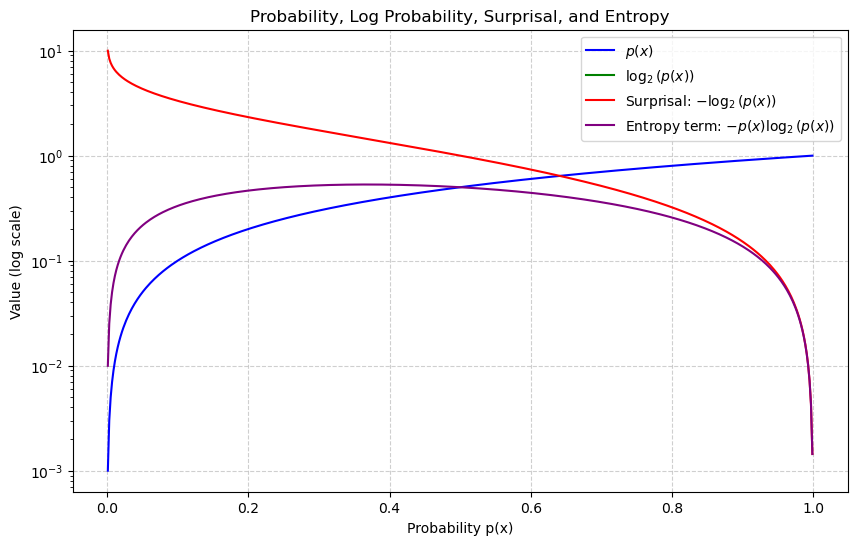

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Probability values
p = np.linspace(0.001, 0.999, 500)

# Functions
px = p
logp = np.log2(p)
surprisal = -np.log2(p)
entropy_term = -p * np.log2(p)

plt.figure(figsize=(10,6))

# Plot each curve
plt.plot(p, px, label=r"$p(x)$", color="blue")
plt.plot(p, logp, label=r"$\log_2(p(x))$", color="green")
plt.plot(p, surprisal, label=r"Surprisal: $-\log_2(p(x))$", color="red")
plt.plot(p, entropy_term, label=r"Entropy term: $-p(x)\log_2(p(x))$", color="purple")

# Formatting
plt.title("Probability, Log Probability, Surprisal, and Entropy")
plt.xlabel("Probability p(x)")
plt.ylabel("Value (log scale)")
plt.yscale("log")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()


# Information Theory and Cross-Entropy (2/5)  

**Coin flip intuition**  
- A fair coin: $H = 1$ bit → completely uncertain.  
- A biased coin: $H < 1$ bit → more predictable.  
- A certain coin: $H = 0$ → no uncertainty.  

**Question for students:**  
How uncertain is this coin flip?  


# Information Theory and Cross-Entropy (3/5)  

**Horse race betting example**   

- Suppose there are **8 horses**.  
- You need to send a **short message** to the bookie to indicate which horse you bet on.  

**Solution #1: Binary encoding**  
- Horse 1 → 001, Horse 2 → 010, Horse 3 → 011, …, Horse 8 → 000  
- Always takes **3 bits** per message.  


# Information Theory and Cross-Entropy (4/5)  

**Solution #2: Use prior probabilities**  

Suppose the horses have different winning probabilities:  

- H#1: 1/2  
- H#2: 1/4  
- H#3: 1/8  
- H#4: 1/16  
- H#5–8: 1/64 each  

**Key idea:**  
- If outcomes are not uniform, we can use shorter codes for more likely horses.  
- Lower-entropy distributions → fewer bits needed on average.  


# Information Theory and Cross-Entropy (5/5)  

**Comparing encoding schemes:**  

- **Uniform distribution (P1):**  
  $P = (1/8, …, 1/8)$  
  - Entropy $H(P_1) = 3$ bits  
  - Each outcome = 3 bits (000, 001, …, 111)  

- **Skewed distribution (P2):**  
  $P = (1/2, 1/4, 1/8, 1/16, 1/64, …)$  
  - Entropy $H(P_2) \approx 2$ bits (on average)  
  - Likely outcomes get short codes (0, 10, 110, 1110, …)  

**Key idea:**  
Entropy = **average bits per outcome**.  
Lower entropy → shorter codes → less uncertainty.  


# Information-theoretic View (1/4)  

**Cross-entropy** measures the quality of predictions.  

- $p$: the *true* distribution of language  
- $m$: our *model’s approximation*  

**Definition:**  

$$
H(p, m) = \lim_{n \to \infty} -\frac{1}{n} \sum_{w} p(W_1, \dots, W_n) 
\log m(W_1, \dots, W_n)
$$  

**Intuition:**  
- Average number of bits needed to encode samples from $p$  
- …when using codes optimized for $m$  
- Lower = better approximation


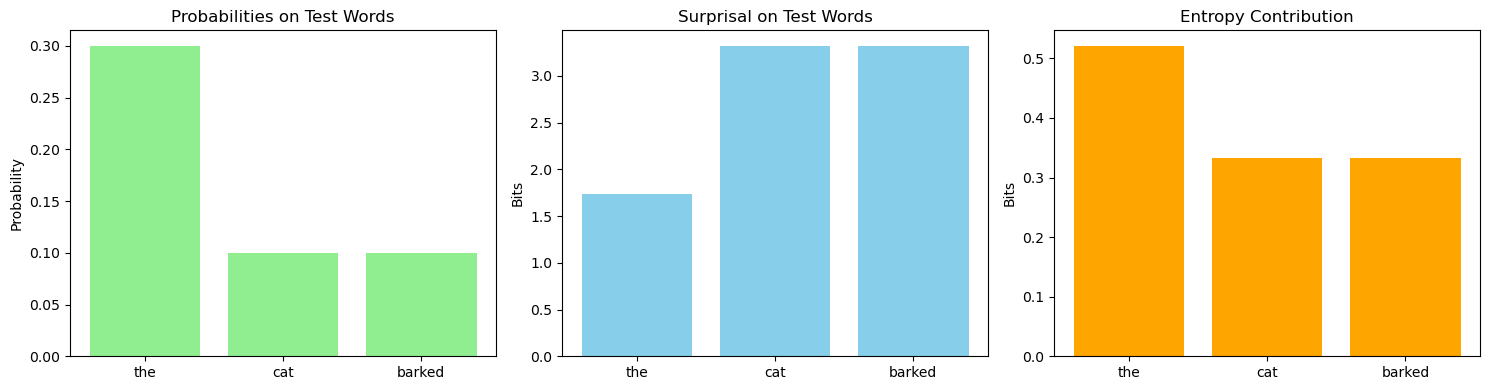

Total Surprisal (Test Set): 8.38 bits
Total Entropy Contribution (Test Set): 1.19 bits


In [26]:
# New train and test corpora with overlap
train_corpus = "the cat sat on the mat and the dog barked".split()
test_corpus = "the cat barked".split()

# Train counts and probabilities
train_counts = Counter(train_corpus)
total_train = sum(train_counts.values())
probs = {word: count / total_train for word, count in train_counts.items()}

# Compute surprisal and entropy contributions for the test set
words = test_corpus
p_vals = np.array([probs.get(w, 0) for w in words])
surprisal_vals = [-np.log2(p) if p > 0 else float('inf') for p in p_vals]
entropy_contribs = [-p * np.log2(p) if p > 0 else 0 for p in p_vals]

# Total surprisal and entropy
total_surprisal = sum(surprisal_vals)
total_entropy = sum(entropy_contribs)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].bar(words, p_vals, color="lightgreen")
ax[0].set_title("Probabilities on Test Words")
ax[0].set_ylabel("Probability")

ax[1].bar(words, surprisal_vals, color="skyblue")
ax[1].set_title("Surprisal on Test Words")
ax[1].set_ylabel("Bits")

ax[2].bar(words, entropy_contribs, color="orange")
ax[2].set_title("Entropy Contribution")
ax[2].set_ylabel("Bits")

plt.tight_layout()
plt.show()

# Print totals
print(f"Total Surprisal (Test Set): {total_surprisal:.2f} bits")
print(f"Total Entropy Contribution (Test Set): {total_entropy:.2f} bits")


# Surprisal in Psycholinguistics (1/2)  

**Definition:**  
The **surprisal** of a word $w_i$ given its context is:  

$$
-\log P_m(w_i \mid \text{context})
$$  

**Interpretation:**  
- High surprisal → word was unexpected (low probability)  
- Low surprisal → word was expected (high probability)  

**Relevance:**  
Surprisal correlates with the amount of **cognitive effort** humans expend during sentence processing.


# Surprisal in Psycholinguistics (2/2)  

**Example sentence:**  
*"I drink my coffee with cream and **socks** in the morning when I get up."*  

Unexpected words (like *socks*) produce higher surprisal. This correlates with measurable cognitive effects:  

- **Longer reading times** (eye-tracking)  
- **Event-related potentials** (e.g., N400, P600 in EEG)  
- **Increased blood oxygen level** (fMRI)  

**Takeaway:**  
Computational language models can predict the **difficulty of human sentence processing**.


# N-gram Length and Performance  

### Does increasing N-gram length always improve language models?  

**Yes — but only up to a point.**  

- Longer context → more accurate conditional probabilities  
- But **data sparsity** grows quickly:  
  - Unigram: $O(V)$ parameters  
  - Bigram: $O(V^2)$ parameters  
  - Trigram: $O(V^3)$ parameters  
- Most higher-order n-grams will have **zero counts** in real data  

**Trade-off:**  
- Larger $N$ captures longer dependencies  
- But requires far more data to estimate reliably


### N-gram Tools and Resources

**"All Our N-gram are Belong to You"** (Reference to classic internet meme)

Popular N-gram modeling toolkits:

**KenLM**
- https://kheafield.com/code/kenlm/

**SRILM**  
- http://www.speech.sri.com/projects/srilm/

**Historical Reference: Google N-Gram Release, August 2006**

The slide shows a reference to Google's massive N-gram dataset release with the title "All Our N-gram are Belong to You" posted by the Google Research team. This was a significant release that provided:

- Enormous datasets of N-grams for a variety of NLP projects
- Counts for 1-grams through 5-grams extracted from a large web corpus
- Over 1 trillion tokens and over 13 million unique words
- This resource was foundational for many NLP research projects

The Google N-gram datasets served as the incoming 52 terms as the incubator 49 terms as the index 233, etc., providing crucial frequency statistics for language modeling research.

<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 3. Hidden Markov Models



# Hidden Markov Models  

### Sequence Modeling: HMMs  

Other sequence models for language include:  
- Conditional Random Fields (CRFs)  
- Structured Perceptrons  
- Neural sequence models (current state of the art)  

**Why study HMMs?** They combine several key NLP ideas:  
- **Latent generative models** (hidden states explain observed words)  
- **Dynamic programming** (efficient algorithms: Forward–Backward, Viterbi)  
- **Noisy channel models** (separating signal from noise in communication)  


# Noisy Channel Models (Decoder Formulation)  

Given observed sequence $W$, we want to recover the most likely hidden sequence $T$:  

$$
T^* = \arg\max_T P(T \mid W)
$$  

Using Bayes’ Rule:  

$$
T^* = \arg\max_T P(T) \, P(W \mid T)
$$  

- **$P(T)$** = source model (prior over hidden sequences)  
- **$P(W \mid T)$** = channel model (likelihood of observed sequence)  

**Key idea:**  
The decoder finds the $T$ that balances:  
- how plausible $T$ is on its own (source)  
- how well $T$ explains the observed $W$ (channel)  
